# Transcriptomic Profiling of Oral Squamous Cell Carcinoma

An auditable reanalysis of **GSE20116**, three matched tumor–normal pairs. This notebook reads genuine pipeline results. Synthetic fixtures exist only under `tests/fixtures`. See [REPORT.md](../REPORT.md) for the research interpretation and [provenance](../data/PROVENANCE.md) for source details.

## 1. Reproduce or load the analysis
Install this project with Python 3.11, then run `oscc run` from the repository root. Subsequent runs can use `oscc run --offline`. This notebook reuses completed results to avoid unnecessarily refitting; uncomment the explicit pipeline call to repeat the computation. No dataset substitutions occur.

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'pyproject.toml').exists(), 'Run from the repository or notebooks directory'
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.tools/matplotlib'))
from oscc.dashboard import load_results
# from oscc.pipeline import run
# run(ROOT, offline=True)  # Requires the cached original sources and GMT.
bundle = load_results(ROOT)
bundle['manifest']['summary']

{'genes': 10541, 'tested': 10506, 'up': 363, 'down': 976}

## 2. Check the source and pairing
GEO supplies legacy MAX alignments. The original paper's Table S1 contains separate raw and normalized columns. The parser explicitly selects raw sums in columns D–I. The cached workbook and GEO SOFT file are checksum-verified by the acquisition command. If raw sources are not yet cached, run `oscc download`. Missing age, sex, stage and HPV fields are not imputed.

In [2]:
metadata = bundle['metadata']
metadata[['patient_id', 'condition', 'source_column', 'tissue', 'sample_url']]

,patient_id,condition,source_column,tissue,sample_url
sample_accession,,,,,
GSM515513,8,normal,8N,Oral cavity normal tissue,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...
GSM515514,8,tumor,8T,Oral squamous cell carcinoma,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...
GSM515515,33,normal,33N,Oral cavity normal tissue,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...
GSM515516,33,tumor,33T,Oral squamous cell carcinoma,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...
GSM515517,51,normal,51N,Oral cavity normal tissue,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...
GSM515518,51,tumor,51T,Oral squamous cell carcinoma,https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi...


In [3]:
from oscc.validation import validate_counts, design_matrix
counts, metadata = validate_counts(bundle['counts'], metadata)
design = design_matrix(metadata)
print('Genes x samples:', counts.shape)
print('Design rank:', np.linalg.matrix_rank(design), '; residual df:', len(metadata) - design.shape[1])
design

Genes x samples: (10541, 6)
Design rank: 4 ; residual df: 2


,Intercept,patient_id_51,patient_id_8,condition_tumor
sample_accession,,,,
GSM515513,1.0,0.0,1.0,0.0
GSM515514,1.0,0.0,1.0,1.0
GSM515515,1.0,0.0,0.0,0.0
GSM515516,1.0,0.0,0.0,1.0
GSM515517,1.0,1.0,0.0,0.0
GSM515518,1.0,1.0,0.0,1.0


## 3. Preprocessing and normalization
The source table was already filtered by its authors. Representatives are selected by maximum exon count, with lexical RefSeq tie-breaking; overlapping isoforms are never summed. An additional abundance-only rule requires at least 10 reads in at least three libraries. The full filter/mapping audits remain available. Raw counts enter the count model; median-of-ratios normalized counts and log2(normalized + 1) serve different purposes. The log transform is not a VST.

In [4]:
filter_audit = pd.read_csv(ROOT / 'results/tables/filter_audit.csv')
print(filter_audit.retained.value_counts())
normalized = bundle['normalized_counts']
log_expression = bundle['log_expression']
assert np.allclose(log_expression, np.log2(normalized + 1))
pd.read_csv(ROOT / 'results/tables/library_sizes.csv')

retained
True    10541
Name: count, dtype: int64


,sample_accession,retained_count_sum,size_factor
0,GSM515513,7944551,0.719652
1,GSM515514,7365969,0.628084
2,GSM515515,15871987,0.831018
3,GSM515516,14198323,1.085691
4,GSM515517,21502237,1.752688
5,GSM515518,15068842,1.423567


## 4. Quality control
PCA uses centered, unscaled log normalized expression of the 2,000 most variable genes. It is not fitted on DE-selected genes. Lines link matched patients; no samples were removed based on plot appearance. Raw-read QC has not been recomputed.

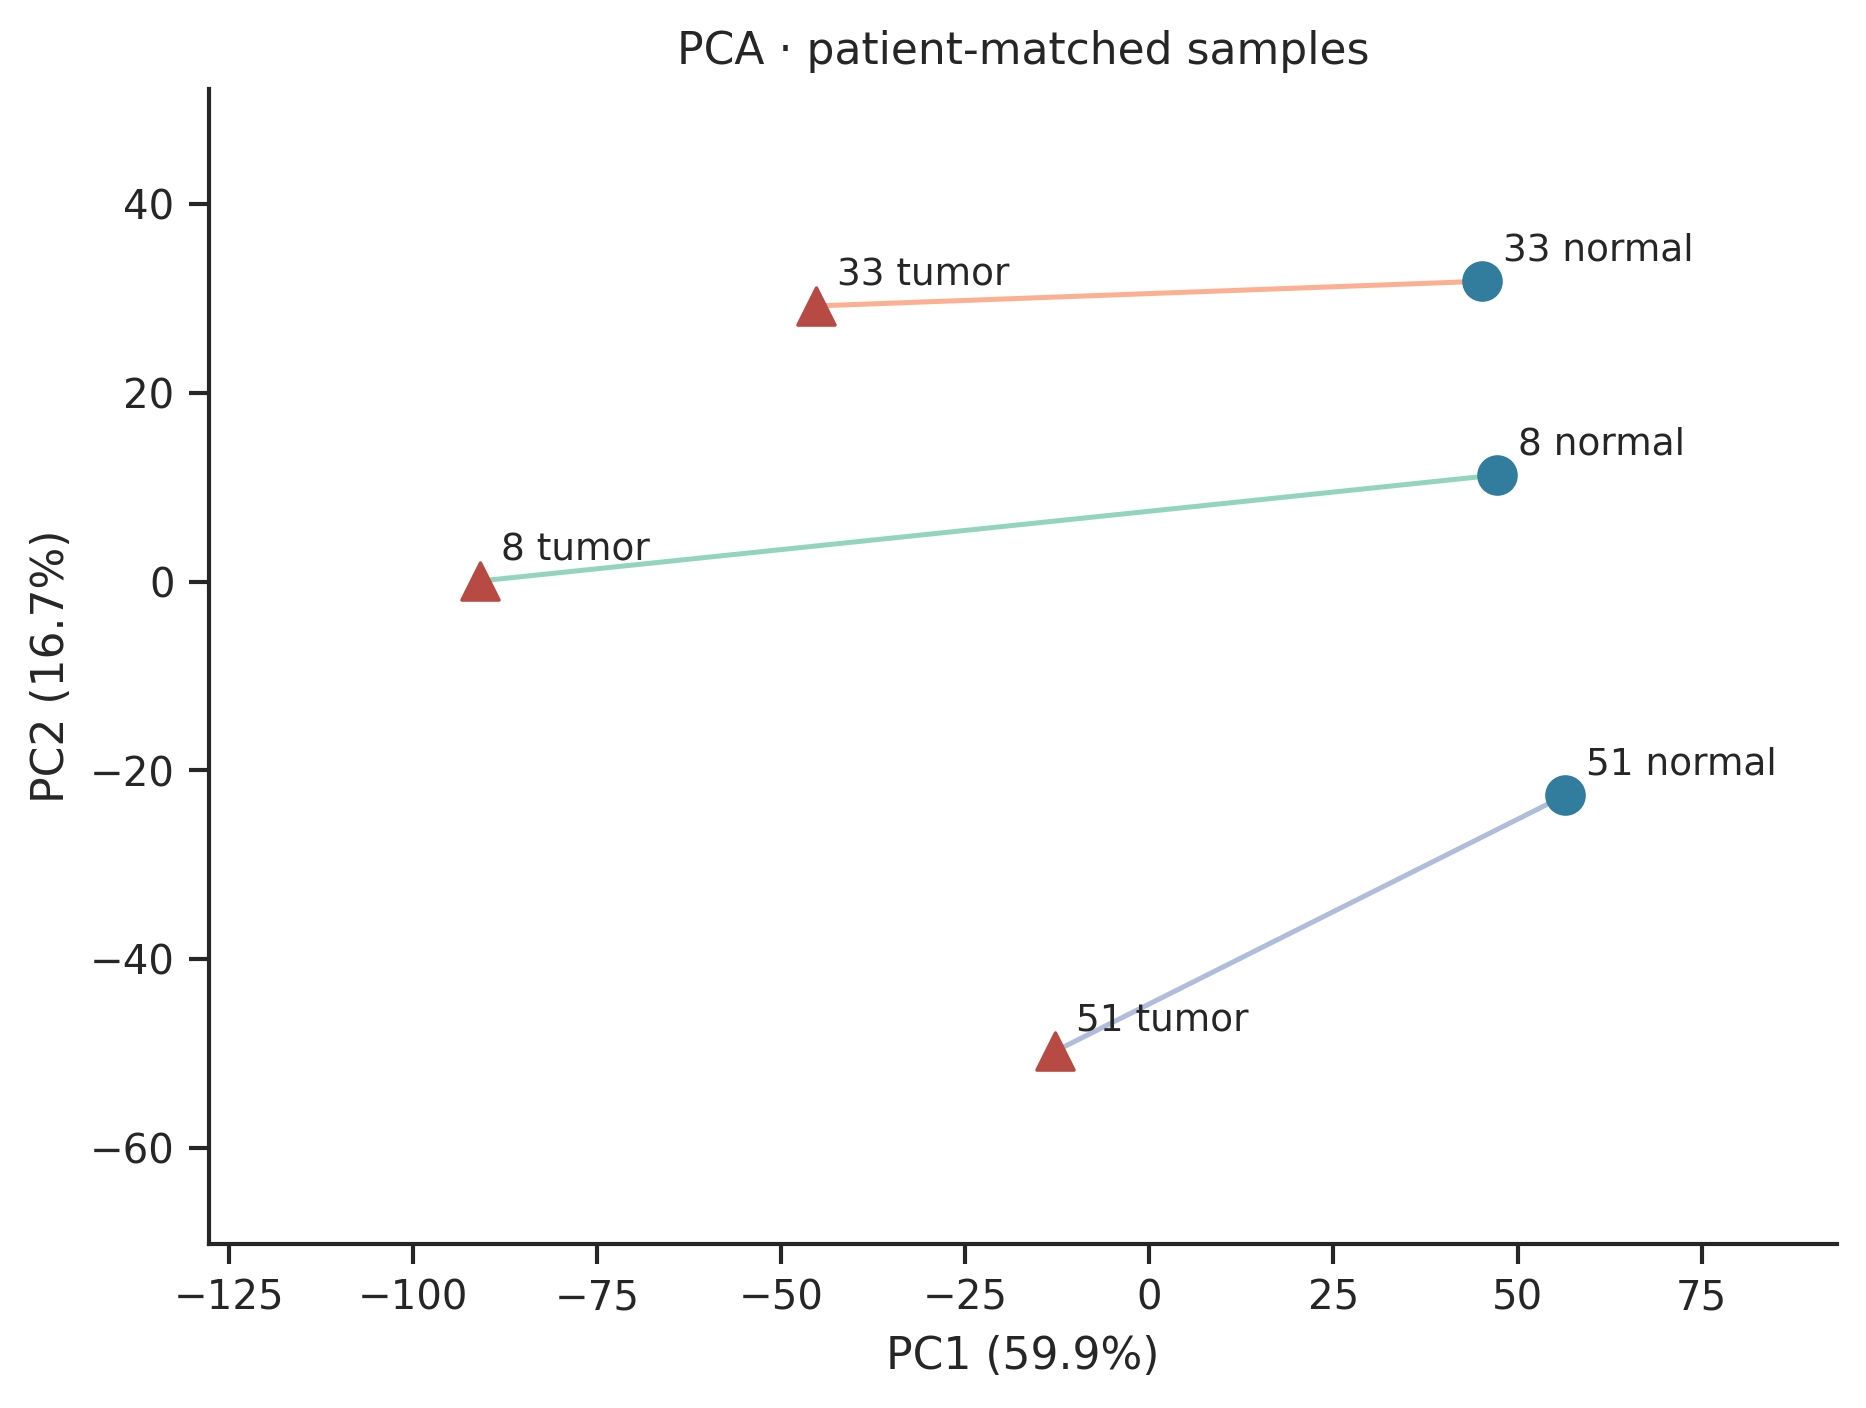

{'library_min': 7365969,
 'library_max': 21502237,
 'correlation_min': 0.6130291336018127,
 'correlation_max': 0.896889336194176,
 'pca_variance': [0.5993163695798145, 0.16668142757817164]}

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'results/figures/pca.png'), width=700))
bundle['manifest']['qc']

## 5. Paired differential expression
PyDESeq2 uses `~ patient_id + condition`, with a tumor/normal Wald contrast. The fit retains convergence flags and excludes failed fits from BH-adjusted calls. No source-publication p-values are reused. The nominal null is LFC = 0; the absolute LFC cutoff is an additional selection rule, not a threshold-null hypothesis test.

In [6]:
from oscc.differential import classify
results = bundle['differential_expression']
calls = classify(results, alpha=.05, lfc=1.)
print(calls.value_counts())
print(bundle['manifest']['diagnostics'])
results.loc[calls != 'not_significant'].sort_values('padj').head(10)

not_significant    9202
down                976
up                  363
Name: count, dtype: int64
{'design': '~patient_id + condition', 'contrast': 'tumor / normal', 'design_rank': 4, 'residual_df': 2, 'failed_convergence': 35, 'missing_pvalue': 35, 'warnings': ['As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.', "Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True ...  True  True  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first."], 'normalization': 'DESeq2 median-of-ratios size factors', 'cooks_filter': True, 'outlier_replacement': False, 'independent_filter': False, 'bh_family': 'all finite, convergence-qualified, Cook-filtered p-values'}


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,pvalue_model,model_converged,test_status,refseq,exons,direction
gene,,,,,,,,,,,,
TMPRSS11B,2537.416266,-7.451125,0.642622,-11.594888,4.374395e-31,4.595740e-27,4.374395e-31,True,tested,NM_182502,10,down
PTGFR,337.099870,-5.199348,0.490070,-10.609405,2.694599e-26,1.415473e-22,2.694599e-26,True,tested,NM_001039585,4,down
PYGM,804.902918,-5.489667,0.519349,-10.570294,4.092109e-26,1.433057e-22,4.092109e-26,True,tested,NM_005609,20,down
CRNN,11573.536143,-7.304206,0.693368,-10.534390,5.997107e-26,1.575140e-22,5.997107e-26,True,tested,NM_016190,3,down
MAL,1623.827705,-6.965040,0.675850,-10.305604,6.647255e-25,1.396721e-21,6.647255e-25,True,tested,NM_002371,4,down
IL1F6,536.753548,-6.193626,0.613209,-10.100347,5.504726e-24,9.175666e-21,5.504726e-24,True,tested,NM_014440,4,down
KRT78,2484.771128,-4.250163,0.421223,-10.090054,6.113617e-24,9.175666e-21,6.113617e-24,True,tested,NM_173352,9,down
MYBPC1,3589.156115,-7.161127,0.721774,-9.921567,3.354471e-23,4.405259e-20,3.354471e-23,True,tested,NM_002465,32,down
MYBPC2,1143.549555,-5.494882,0.557491,-9.856448,6.428363e-23,7.504042e-20,6.428363e-23,True,tested,NM_004533,28,down


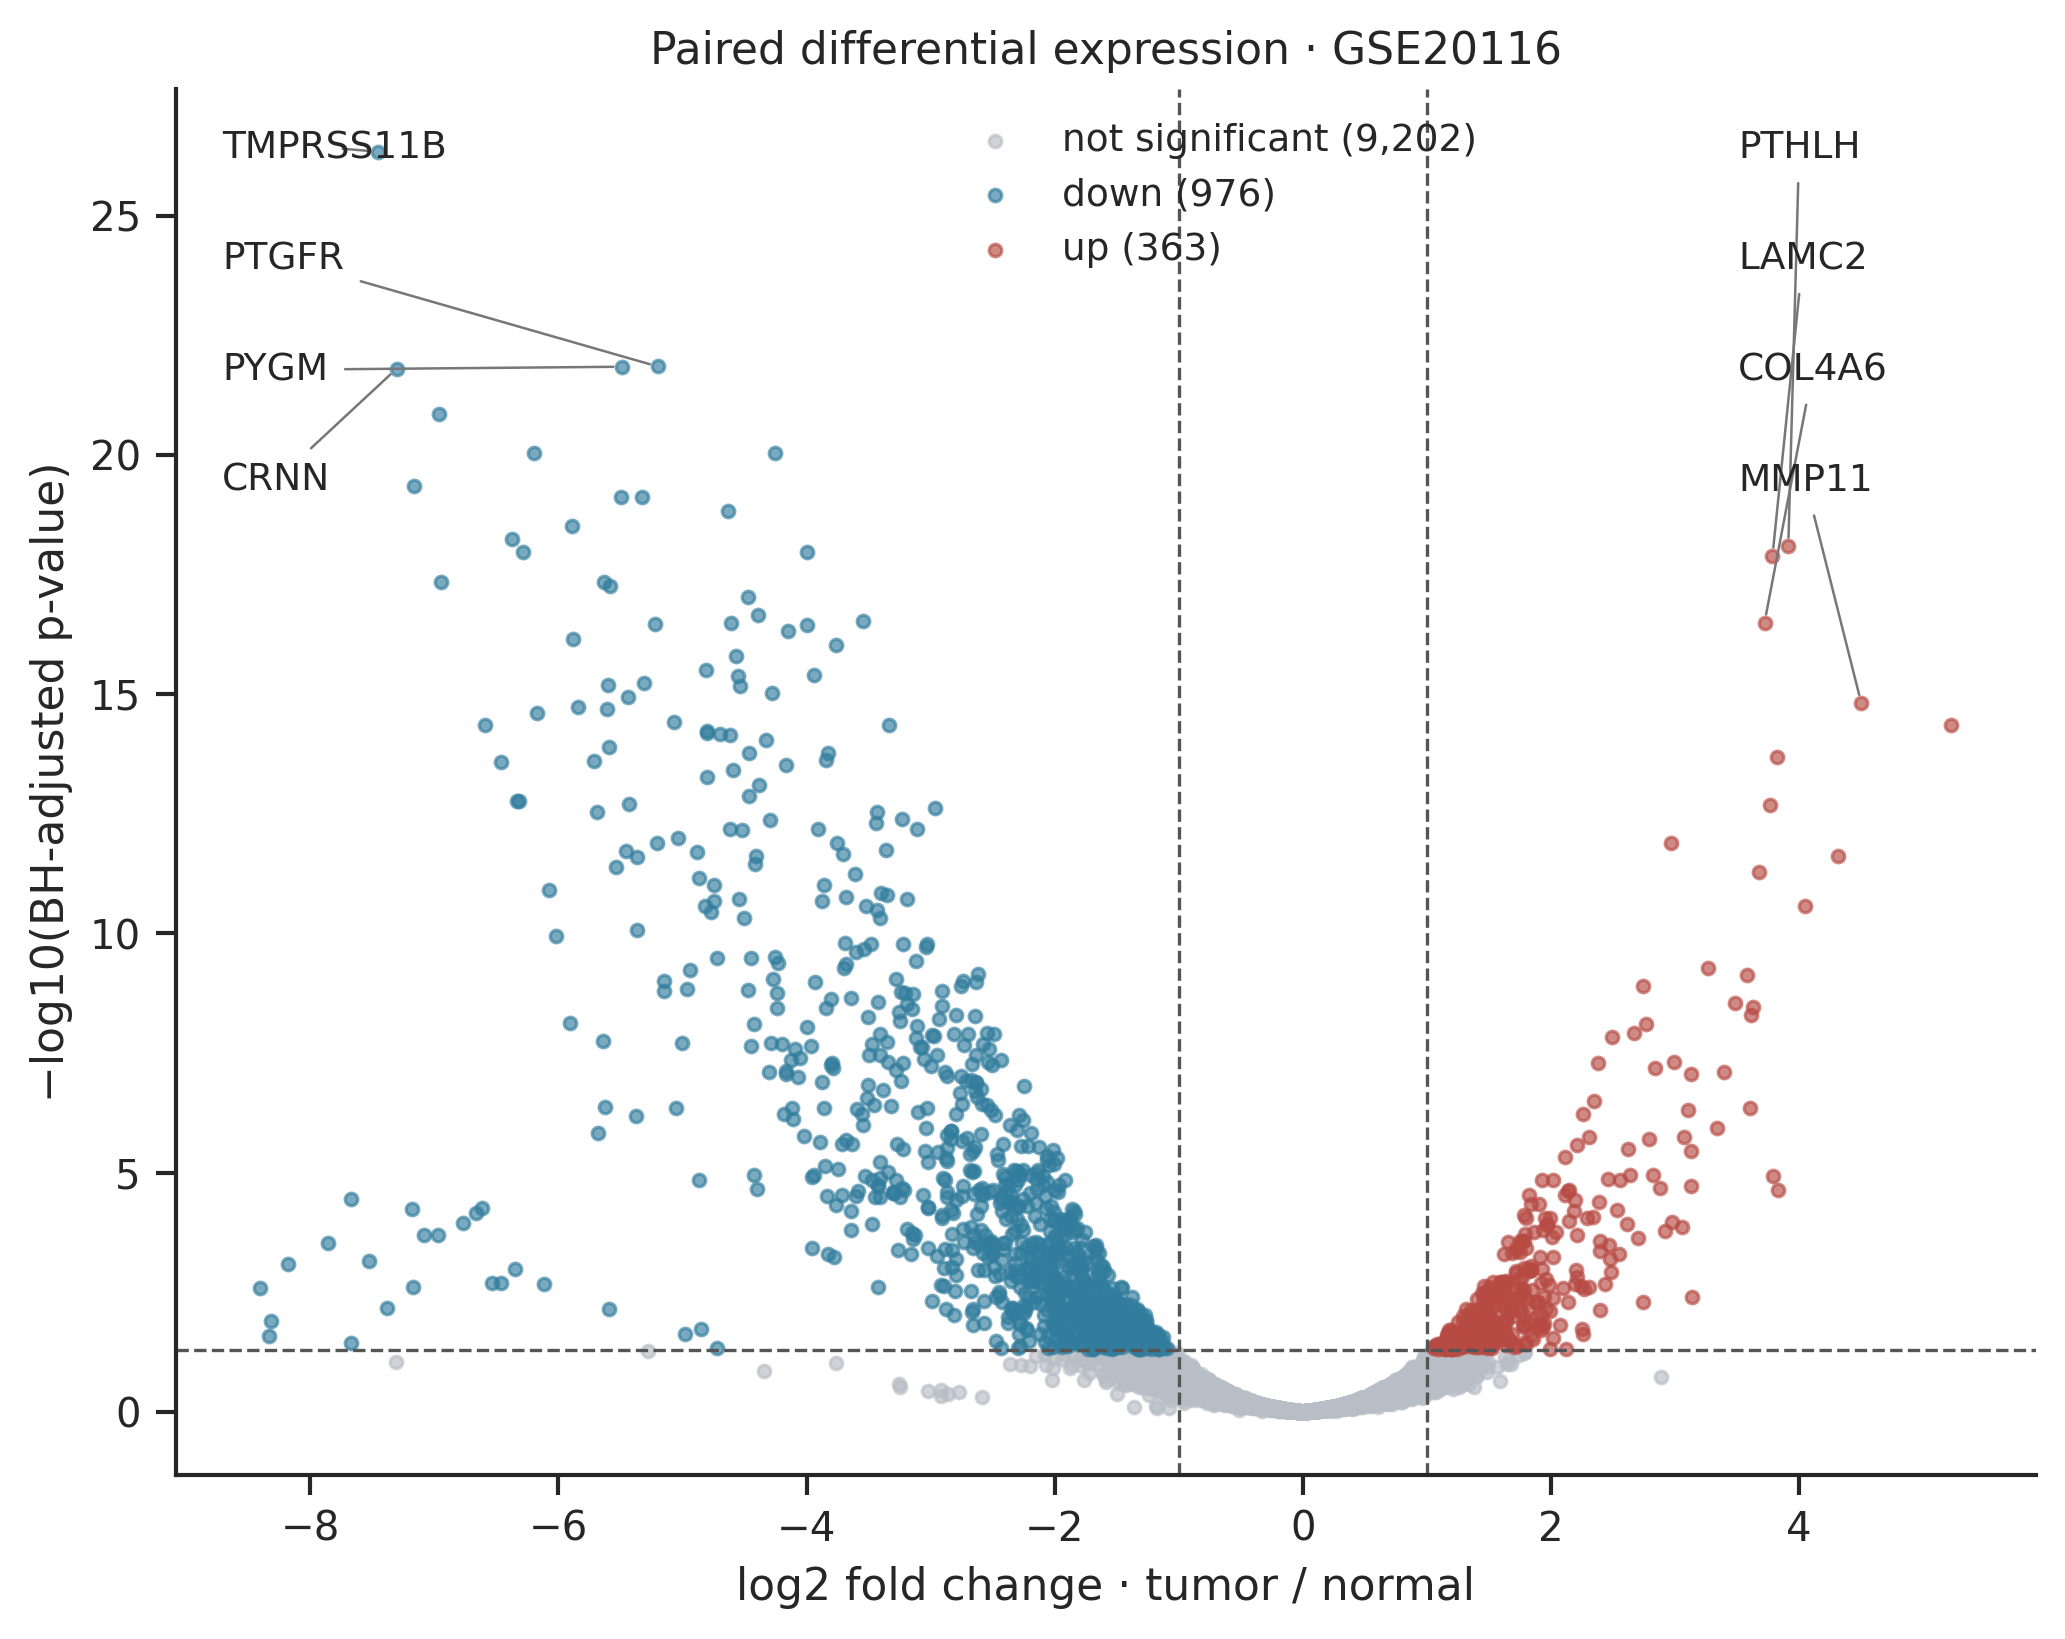

In [7]:
display(Image(filename=str(ROOT / 'results/figures/volcano.png'), width=800))

## 6. Inspect a real candidate
The selected gene below is chosen from the computed results, not supplied as a presumed cancer marker. Compare each patient's normalized measurements and note that expression differences do not imply causality.

In [8]:
from oscc.dashboard import gene_expression
candidate = results.loc[results.padj.notna()].sort_values('padj').index[0]
print(candidate)
gene_expression(bundle, candidate)

TMPRSS11B


,sample_accession,patient_id,condition,log_expression,normalized_count
0,GSM515513,8,normal,11.814879,3601.741294
1,GSM515514,8,tumor,2.530179,4.776434
2,GSM515515,33,normal,13.197384,9392.091561
3,GSM515516,33,tumor,8.212687,295.664157
4,GSM515517,51,normal,10.910569,1923.902003
5,GSM515518,51,tumor,2.872267,6.322148


## 7. Pathway enrichment
Preranked GSEA uses signed Wald statistics and 1,000 gene-set permutations with seed 42. Positive NES points toward tumor-upregulated genes. ORA uses significant up/down lists and the tested-gene background. GSEA FDR and ORA BH values are different corrections. Terms are displayed regardless of significance; zero permutation estimates are resolution-limited. Historical symbols are matched exactly; unmatched symbols are audited.

In [9]:
gsea = bundle['gsea']
gsea.sort_values('padj')[['Term', 'NES', 'pvalue', 'padj', 'genes']].head(10) if not gsea.empty else 'No enrichment results; see manifest status'

,Term,NES,pvalue,padj,genes
0,E2F Targets,2.605006,0.000000,0.000000,TFRC;HMGA1;TOP2A;AURKB;MYBL2;MCM2;KIF2C;MTHFD2...
1,Myogenesis,-2.565399,0.000000,0.000000,PYGM;DES;ATP2A1;ACTA1;IGF1;LDB3;FHL1;ENO3;RYR1...
2,Myc Targets V1,2.358091,0.000000,0.000000,ODC1;MCM2;MCM7;YWHAQ;CDC20;PSMD3;HPRT1;XPOT;NC...
3,mTORC1 Signaling,2.168543,0.000000,0.000000,SLC2A1;SQLE;SLC7A11;GCLC;TRIB3;G6PD;SLC7A5;DDI...
4,G2-M Checkpoint,2.110880,0.000000,0.000000,SQLE;ODC1;UBE2C;CDC6;SLC7A5;HMGA1;TOP2A;AURKB;...
5,Myc Targets V2,1.880005,0.000000,0.001320,PLK1;NIP7;MYBBP1A;PUS1;PES1;PLK4;MCM5;WDR43;NO...
6,Glycolysis,1.775273,0.000000,0.003299,MET;AGRN;GCLC;TPBG;KDELR3;PYGB;G6PD;CHPF;GPC1;...
7,Adipogenesis,-1.772630,0.000000,0.003941,GPX3;SORBS1;ITGA7;FZD4;C3;SPARCL1;CRAT;ENPP2;C...
8,Unfolded Protein Response,1.649666,0.008000,0.012253,KDELR3;SLC7A5;DDIT4;CEBPB;MTHFD2;VEGFA;ASNS;PD...
9,KRAS Signaling Dn,-1.647659,0.005959,0.018608,PTGFR;RYR1;KRT13;SPRR3;ACTC1;MYOT;ZBTB16;EGF;K...


In [10]:
ora = bundle['ora']
ora.sort_values('padj').head(10) if not ora.empty else 'No eligible ORA results'

,library,direction,Term,overlap,set_size,query_size,background_size,fold_enrichment,pvalue,padj,genes
64,MSigDB_Hallmark_2020,down,Myogenesis,67,151,976,10506,4.776232,3.252912e-30,1.593927e-28,ACHE;ACTA1;ACTC1;ACTN2;AGL;AK1;APLNR;APOD;ATP2...
29,MSigDB_Hallmark_2020,up,Epithelial Mesenchymal Transition,23,160,363,10506,4.160434,5.816312e-09,2.849993e-07,COL11A1;COL7A1;CTHRC1;EDIL3;ENO2;GPC1;INHBA;IT...
34,MSigDB_Hallmark_2020,up,Glycolysis,20,148,363,10506,3.911101,1.663113e-07,4.074628e-06,ADORA2B;AGRN;CHPF;CHST2;DDIT4;ENO2;FKBP4;G6PD;...
13,MSigDB_Hallmark_2020,up,Estrogen Response Late,18,139,363,10506,3.747904,1.314341e-06,2.146757e-05,CA2;CDC6;CDH1;CELSR2;CKB;CYP26B1;CYP4F11;DHCR7...
96,MSigDB_Hallmark_2020,down,KRAS Signaling Up,28,123,976,10506,2.450420,5.947437e-06,1.457122e-04,AKAP12;APOD;BIRC3;CAB39L;CFB;CFH;DOCK2;EMP1;EN...
47,MSigDB_Hallmark_2020,up,KRAS Signaling Up,15,123,363,10506,3.529530,2.101655e-05,2.574527e-04,BPGM;CA2;EPHB2;ETV4;F2RL1;GPNMB;INHBA;ITGA2;MM...
1,MSigDB_Hallmark_2020,up,Hypoxia,16,141,363,10506,3.284215,2.786994e-05,2.731254e-04,ADORA2B;CHST2;DDIT4;EFNA1;ENO2;GPC1;KDELR3;KLF...
78,MSigDB_Hallmark_2020,down,Epithelial Mesenchymal Transition,32,160,976,10506,2.152869,2.317047e-05,3.784509e-04,ABI3BP;ACTA2;CAP2;COMP;CXCL12;DAB2;DCN;DPYSL3;...
90,MSigDB_Hallmark_2020,down,Coagulation,19,79,976,10506,2.588893,8.323365e-05,8.156898e-04,A2M;ANXA1;C1QA;C1S;C3;CAPN5;CFB;CFD;CFH;CFI;CL...
87,MSigDB_Hallmark_2020,down,UV Response Dn,25,118,976,10506,2.280581,6.658804e-05,8.156898e-04,CAP2;CDON;DAB2;DLC1;DUSP1;EFEMP1;FBLN5;FYN;ICA...


## 8. Interpretation and next steps
Three patients leave only two residual degrees of freedom. Historical technology, source prefiltering, representative-transcript selection, incomplete annotation and tissue-composition differences restrict interpretation. Same-cohort agreement with Tuch et al. is not independent replication. Validate candidates in an independent anatomically matched OSCC cohort and with appropriately designed qPCR or perturbation experiments. Read the generated report and figure captions before quoting results.

Launch the interactive explorer with `streamlit run app/streamlit_app.py`.

References: [Tuch et al.](https://doi.org/10.1371/journal.pone.0009317), [DESeq2](https://doi.org/10.1186/s13059-014-0550-8), [PyDESeq2](https://doi.org/10.1093/bioinformatics/btad547), [GSEApy](https://doi.org/10.1093/bioinformatics/btac757).